# Flight Delay Intelligence System — SHAP Explainability
- This notebook explains WHY the XGBoost model makes each prediction using SHAP values.
- SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every prediction.


In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt

## 1. Load Model and Data

In [ ]:
with open("models/xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

In [ ]:
df = pd.read_csv("data/processed/flights_features.csv")

In [7]:
FEATURE_COLS = ['CRS_DEP_TIME','CRS_ARR_TIME','DISTANCE','MONTH',
                'DAY_OF_WEEK','CARRIER_ENCODED','ORIGIN_ENCODED','DEST_ENCODED']

In [6]:
X = df[FEATURE_COLS]
y = df['ARR_DEL15']

In [8]:
print(X.shape)

(2944078, 8)


## 2. Sample for SHAP
SHAP is computationally expensive. Use 5000 rows for analysis.

In [9]:
X_sample = X.sample(n=5000, random_state=42)

## 3. Create SHAP Explainer
- TreeExplainer is optimized for tree-based models (XGBoost, Random Forest, LightGBM).
- Much faster than the generic KernelExplainer.

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (5000, 8)


## 4. Global Feature Importance
Which features matter most across ALL predictions?

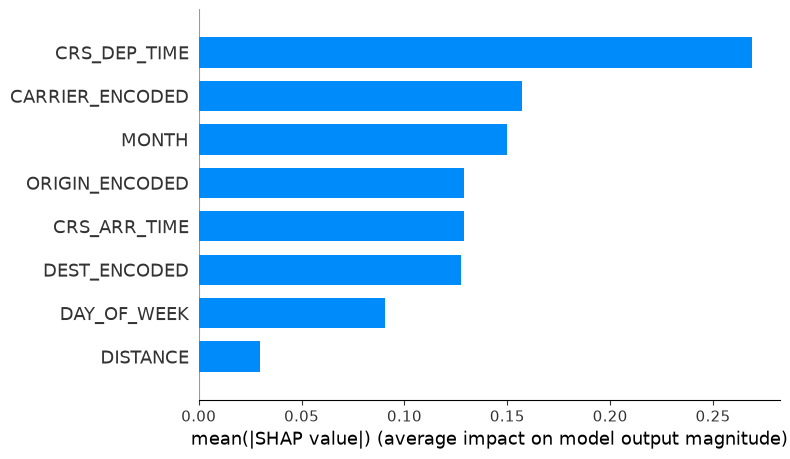

In [30]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)

## 5. SHAP Beeswarm Plot
Shows direction of impact — does high DISTANCE increase or decrease delay probability?

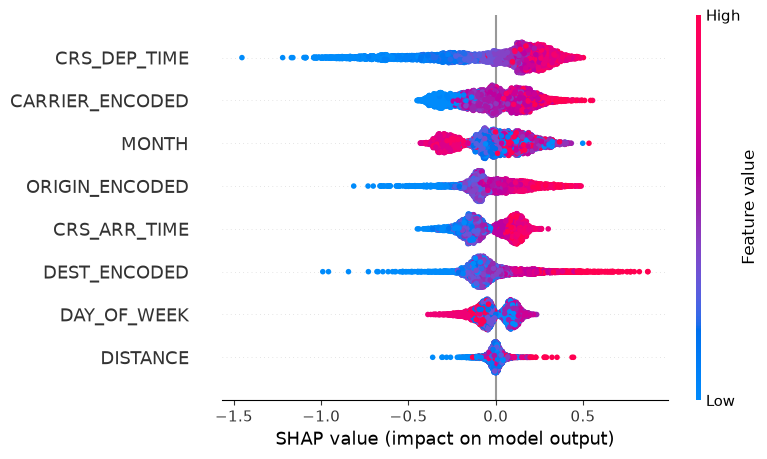

In [22]:
shap.summary_plot(shap_values, X_sample)

## 6. Individual Prediction Explanation
Explain a single flight prediction — why did the model predict delay for this specific flight?

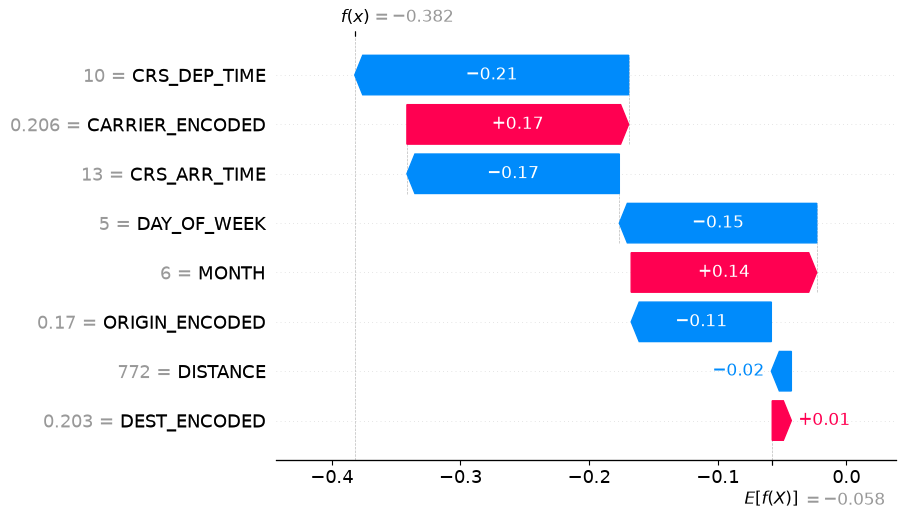

In [17]:
idx = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[idx],
    feature_names=FEATURE_COLS
))

## 7. Dependence Plot — Departure Hour
How does departure hour affect delay probability?

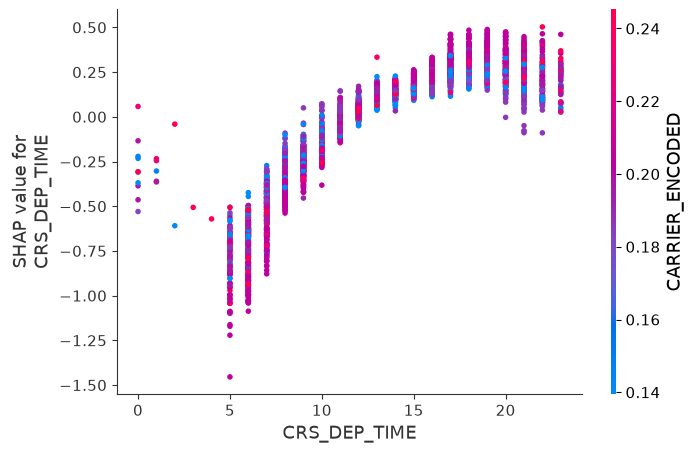

In [18]:
shap.dependence_plot("CRS_DEP_TIME", shap_values, X_sample)

## 8. Key Findings

**Feature Importance (Global):**
- `CRS_DEP_TIME` is the single most important feature by far — departure hour drives delay probability more than any other factor
- `CARRIER_ENCODED` and `MONTH` are second and third — airline choice and season matter significantly
- `DISTANCE` is least important — how far you fly barely affects delay probability

**Beeswarm Insights:**
- `CRS_DEP_TIME` — blue (early hours) strongly reduces delay probability, red (late hours) strongly increases it. Clearest directional signal in the model
- `CARRIER_ENCODED` — high delay rate carriers (red) push prediction toward delayed, low delay rate carriers (blue) push toward on time
- `MONTH` — red (summer months June/July) increase delay probability, blue (fall months) reduce it
- `DISTANCE` — clustered near 0, confirms it has minimal directional impact

**Waterfall (Single Flight — 10AM departure, Saturday, June):**
- Departure at 10AM (-0.21) and Saturday (-0.15) both reduce delay probability
- But carrier has high delay rate (+0.17) and June month (+0.14) push it up
- Net result: model predicts on time (f(x) = -0.382)

**Dependence Plot — CRS_DEP_TIME:**
- 5-6 AM flights: SHAP values around -1.5 — massive reduction in delay probability
- 18-22 PM flights: SHAP values around +0.4 — significant increase
- Perfectly confirms EDA finding — book early morning for lowest delay risk